# XGBoost

**Objective**: Train an XGBoost regressor to predict `Unit Price ($ psf)` and compare against Ridge and Random Forest.

**Key differences from Random Forest**:
- **Boosting vs Bagging**: RF builds trees in parallel independently; XGBoost builds trees sequentially — each tree corrects the residual errors of the previous ones
- More hyperparameters to control overfitting: `learning_rate`, `subsample`, `colsample_bytree`
- Generally achieves lower bias than RF but requires more careful tuning

**Steps:**
1. Load preprocessed train/test splits
2. Baseline XGBoost with 5-fold CV
3. Hyperparameter tuning — GridSearchCV
4. Evaluate on test set — RMSE, MAE, R²
5. Feature importance
6. Compare with Ridge and Random Forest
7. Save model

---

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

os.makedirs("../nb_models", exist_ok=True)

X_train = pd.read_csv("../nb_models/X_train.csv")
X_test  = pd.read_csv("../nb_models/X_test.csv")
y_train = pd.read_csv("../nb_models/y_train.csv")
y_test  = pd.read_csv("../nb_models/y_test.csv")

y_train_raw = y_train["Unit Price ($ psf)"]
y_test_raw  = y_test["Unit Price ($ psf)"]

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Target — Train mean: ${y_train_raw.mean():.2f} $/psf | Test mean: ${y_test_raw.mean():.2f} $/psf")

X_train: (3031, 27)  X_test: (758, 27)
Target — Train mean: $439.23 $/psf | Test mean: $449.48 $/psf


## 2. Baseline — 5-Fold Cross-Validation

Default XGBoost (100 trees, learning_rate=0.3) as a starting point.

**How boosting works**: Each tree is fit on the **residuals** of all previous trees. Tree 1 makes a rough prediction; Tree 2 corrects Tree 1's errors; Tree 3 corrects the remaining errors, and so on. The final prediction is the sum of all trees' outputs.

In [2]:
baseline_xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)

cv_scores = cross_val_score(
    baseline_xgb, X_train, y_train_raw,
    cv=5, scoring="neg_root_mean_squared_error"
)
cv_rmse = -cv_scores

print("Baseline XGBoost (100 trees, default params) — 5-Fold CV:")
for i, rmse in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: ${rmse:.2f} $/psf")
print(f"\n  Mean RMSE: ${cv_rmse.mean():.2f} $/psf")
print(f"  Std RMSE:  ${cv_rmse.std():.2f} $/psf")

Baseline XGBoost (100 trees, default params) — 5-Fold CV:
  Fold 1: $58.52 $/psf
  Fold 2: $56.70 $/psf
  Fold 3: $52.43 $/psf
  Fold 4: $51.35 $/psf
  Fold 5: $51.35 $/psf

  Mean RMSE: $54.07 $/psf
  Std RMSE:  $2.97 $/psf


## 3. Hyperparameter Tuning — GridSearchCV

Key hyperparameters for XGBoost:

| Parameter | Effect |
|---|---|
| `n_estimators` | Number of boosting rounds (trees) |
| `max_depth` | Max depth per tree — lower = more regularisation |
| `learning_rate` | Shrinks each tree's contribution — lower rate needs more trees to compensate |
| `subsample` | Fraction of training rows sampled per tree — adds randomness, reduces overfitting |
| `colsample_bytree` | Fraction of features sampled per tree — similar to `max_features` in RF |

In [3]:
param_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [3, 5, 7],
    "learning_rate":    [0.05, 0.1, 0.3],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
grid_search.fit(X_train, y_train_raw)

print(f"\nBest parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: ${-grid_search.best_score_:.2f} $/psf")

Fitting 5 folds for each of 72 candidates, totalling 360 fits



Best parameters:
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 7
  n_estimators: 200
  subsample: 0.8

Best CV RMSE: $50.80 $/psf


In [4]:
# Show top 10 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["cv_rmse"]    = -results_df["mean_test_score"]
results_df["train_rmse"] = -results_df["mean_train_score"]

top10 = results_df.nsmallest(10, "cv_rmse")[
    ["param_n_estimators", "param_max_depth", "param_learning_rate",
     "param_subsample", "param_colsample_bytree", "train_rmse", "cv_rmse"]
].reset_index(drop=True)

top10.columns = ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", "Train RMSE ($/psf)", "CV RMSE ($/psf)"]
print("Top 10 parameter combinations:")
print(top10.to_string(index=False))

Top 10 parameter combinations:
 n_estimators  max_depth  learning_rate  subsample  colsample_bytree  Train RMSE ($/psf)  CV RMSE ($/psf)
          200          7           0.05        0.8               0.8           22.175917        50.802193
          100          7           0.10        0.8               0.8           22.197843        50.937277
          200          5           0.10        1.0               1.0           28.101573        50.955681
          200          7           0.10        1.0               0.8           15.257630        50.990465
          200          7           0.10        0.8               0.8           13.756645        51.098032
          100          7           0.10        1.0               0.8           22.838677        51.269168
          200          7           0.05        1.0               0.8           23.100020        51.279479
          200          7           0.05        0.8               1.0           21.197042        51.412300
          200  

## 4. Test Set Evaluation

In [5]:
best_model = grid_search.best_estimator_

y_pred_raw = best_model.predict(X_test)
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mae_raw  = np.mean(np.abs(y_test_raw.values - y_pred_raw))
r2_raw   = r2_score(y_test_raw, y_pred_raw)

print(f"Best parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print()
print(f"--- Test Set Results (Unit Price $ psf) ---")
print(f"  RMSE: ${rmse_raw:.2f} $/psf")
print(f"  MAE:  ${mae_raw:.2f} $/psf")
print(f"  R²:   {r2_raw:.4f}")
print()
print(f"Mean actual price:    ${y_test_raw.mean():.2f} $/psf")
print(f"RMSE as % of mean:    {rmse_raw / y_test_raw.mean() * 100:.1f}%")
print()
print(f"RMSE vs MAE: ${rmse_raw:.2f} vs ${mae_raw:.2f} $/psf  (gap = ${rmse_raw - mae_raw:.2f} $/psf)")
print(f"  -> {'RMSE >> MAE: model has some large outlier errors worth investigating' if (rmse_raw - mae_raw) > 20 else 'RMSE close to MAE: errors are fairly uniform, no severe outlier predictions'}")

Best parameters:
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 7
  n_estimators: 200
  subsample: 0.8

--- Test Set Results (Unit Price $ psf) ---
  RMSE: $48.80 $/psf
  MAE:  $32.48 $/psf
  R²:   0.9267

Mean actual price:    $449.48 $/psf
RMSE as % of mean:    10.9%

RMSE vs MAE: $48.80 vs $32.48 $/psf  (gap = $16.31 $/psf)
  -> RMSE close to MAE: errors are fairly uniform, no severe outlier predictions


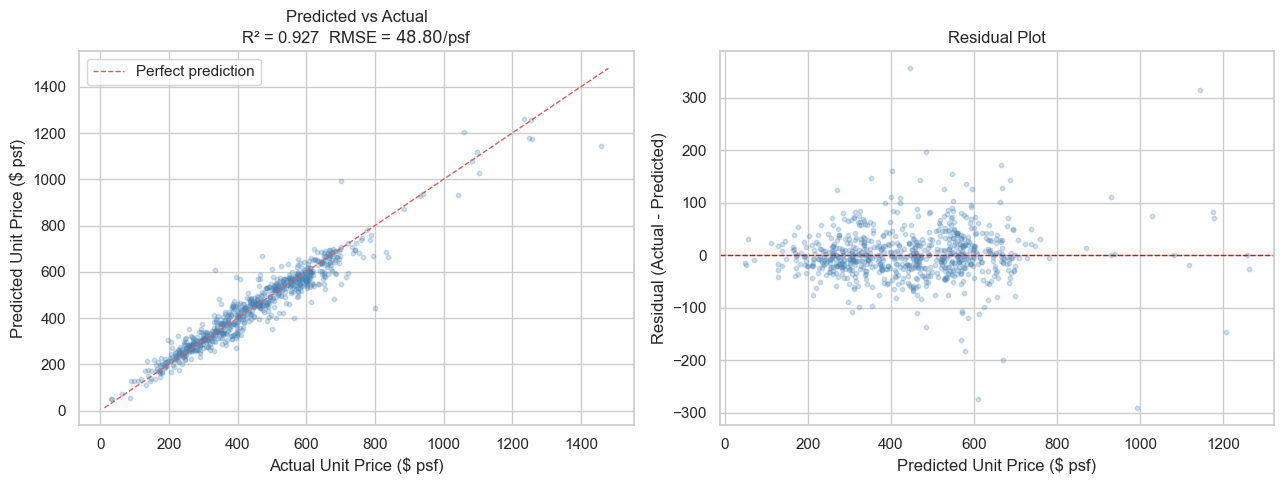

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(y_test_raw, y_pred_raw, alpha=0.25, s=10, color="steelblue")
lims = [min(y_test_raw.min(), y_pred_raw.min()) - 20,
        max(y_test_raw.max(), y_pred_raw.max()) + 20]
axes[0].plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("Actual Unit Price ($ psf)")
axes[0].set_ylabel("Predicted Unit Price ($ psf)")
axes[0].set_title(f"Predicted vs Actual\nR² = {r2_raw:.3f}  RMSE = ${rmse_raw:.2f} $/psf")
axes[0].legend()

# Residuals
residuals = y_test_raw.values - y_pred_raw
axes[1].scatter(y_pred_raw, residuals, alpha=0.25, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Unit Price ($ psf)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

## 5. Feature Importance

XGBoost provides **gain-based feature importance** — the average improvement in loss (MSE reduction) each feature contributes when used in a split.

Gain is generally more reliable than impurity-based importance (used by RF) as it accounts for how much each split actually improves predictions, not just how frequently a feature is used.

In [7]:
importances = best_model.feature_importances_
feature_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Feature Importances (gain-based):")
print(importance_df.to_string(index=False))
print(f"\nTop 3 features account for {importance_df['Importance'].head(3).sum()*100:.1f}% of total importance")

Feature Importances (gain-based):
                    Feature  Importance
        Type of Sale_Resale    0.192872
      Planning_Area_Encoded    0.178861
      Remaining_Lease_Years    0.138889
              dist_to_mrt_m    0.078556
        Region_North Region    0.066967
         Region_West Region    0.048016
                   Log_Area    0.043546
Floor Level_Non-First Floor    0.031943
        Floor Level_Unknown    0.030221
      Lease_Remaining_Ratio    0.029928
         Region_East Region    0.022028
                  1Y_TBills    0.018172
      Steel_Rebar_Per_Tonne    0.017896
         SORA_3M_Compounded    0.010063
   Region_North-East Region    0.009526
              CPI_All_Items    0.009031
              5Y_Bond_Yield    0.008866
              2Y_Bond_Yield    0.008129
             10Y_Bond_Yield    0.007834
      Cement_Bulk_Per_Tonne    0.007570
             15Y_Bond_Yield    0.007527
  Concreting_Sand_Per_Tonne    0.007354
             20Y_Bond_Yield    0.006636
Ready_

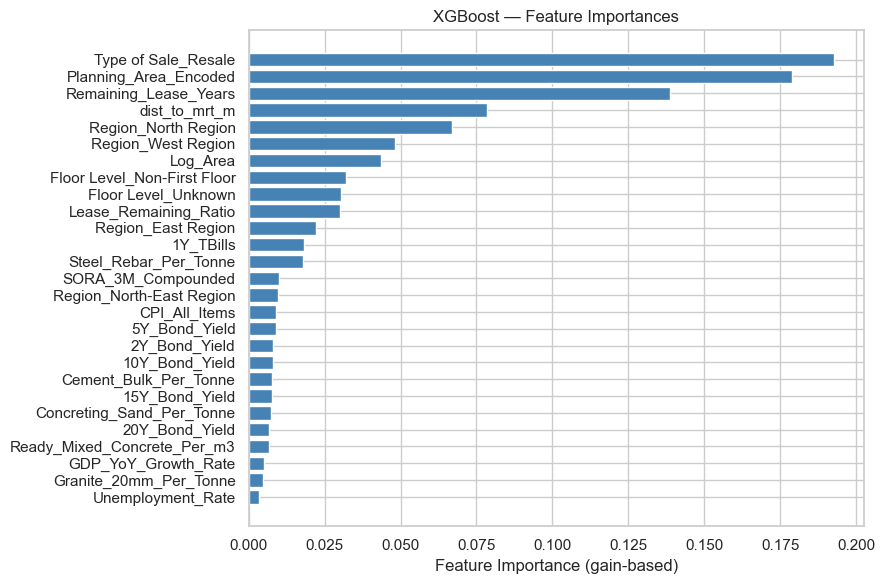

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1],
    color="steelblue"
)
ax.set_xlabel("Feature Importance (gain-based)")
ax.set_title("XGBoost — Feature Importances")
plt.tight_layout()
plt.show()

## 6. Comparison — Ridge vs Random Forest vs XGBoost

In [9]:
ridge_model = joblib.load("../nb_models/ridge_pipeline.pkl")
rf_model    = joblib.load("../nb_models/random_forest.pkl")

y_pred_ridge = np.exp(ridge_model.predict(X_test))
y_pred_rf    = rf_model.predict(X_test)

def eval_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true.values - y_pred))
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

rmse_r, mae_r, r2_r = eval_metrics(y_test_raw, y_pred_ridge)
rmse_f, mae_f, r2_f = eval_metrics(y_test_raw, y_pred_rf)
rmse_x, mae_x, r2_x = eval_metrics(y_test_raw, y_pred_raw)

comparison = pd.DataFrame({
    "Model":          ["Ridge Regression", "Random Forest", "XGBoost"],
    "RMSE ($/psf)":   [f"${rmse_r:.2f}", f"${rmse_f:.2f}", f"${rmse_x:.2f}"],
    "MAE ($/psf)":    [f"${mae_r:.2f}", f"${mae_f:.2f}", f"${mae_x:.2f}"],
    "R²":             [f"{r2_r:.4f}", f"{r2_f:.4f}", f"{r2_x:.4f}"],
    "RMSE % of mean": [f"{rmse_r/y_test_raw.mean()*100:.1f}%",
                       f"{rmse_f/y_test_raw.mean()*100:.1f}%",
                       f"{rmse_x/y_test_raw.mean()*100:.1f}%"],
})

print(comparison.to_string(index=False))

           Model RMSE ($/psf) MAE ($/psf)     R² RMSE % of mean
Ridge Regression       $88.29      $65.34 0.7599          19.6%
   Random Forest       $52.12      $34.42 0.9163          11.6%
         XGBoost       $48.80      $32.48 0.9267          10.9%


## 7. Save Model

In [10]:
joblib.dump(best_model, "../nb_models/xgboost.pkl")

print("Saved: nb_models/xgboost.pkl")
print()
print("=" * 50)
print("XGBOOST SUMMARY")
print("=" * 50)
for k, v in grid_search.best_params_.items():
    print(f"{k+':':25s} {v}")
print()
print(f"CV RMSE:             ${-grid_search.best_score_:.2f} $/psf")
print(f"Test RMSE:           ${rmse_x:.2f} $/psf")
print(f"Test MAE:            ${mae_x:.2f} $/psf")
print(f"Test R²:             {r2_x:.4f}")
print(f"RMSE as % of mean:   {rmse_x / y_test_raw.mean() * 100:.1f}%")

Saved: nb_models/xgboost.pkl

XGBOOST SUMMARY
colsample_bytree:         0.8
learning_rate:            0.05
max_depth:                7
n_estimators:             200
subsample:                0.8

CV RMSE:             $50.80 $/psf
Test RMSE:           $48.80 $/psf
Test MAE:            $32.48 $/psf
Test R²:             0.9267
RMSE as % of mean:   10.9%
